# II. HORIZON TILING OF THE SKY

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb

In [14]:
# Set up the cosmological parameters
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
results = camb.get_background(pars)

z_values = np.linspace(1e-4, 2000, 2000)

In [15]:
d_com = results.comoving_radial_distance(z_values) # comoving distance between z=0 and z=z_values
d_ang = d_com / (1+z_values)

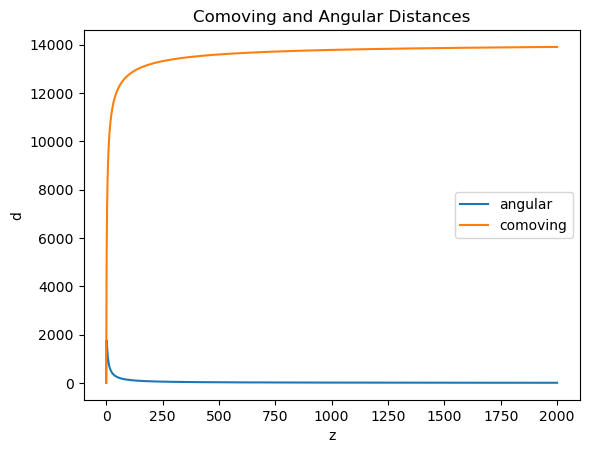

In [16]:
plt.plot(z_values,d_ang)
plt.plot(z_values,d_com)
plt.xlabel('z')
plt.ylabel('d')
plt.legend(['angular','comoving'])
plt.title('Comoving and Angular Distances')
plt.show()

- **Comoving distance** ($d_C$): It is zero at redshift $z = 0$ (our current observing location). As $z$ increases, it grows monotonically and asymptotically approaches the limit of the cosmological horizon, which corresponds to the maximum distance light could have traveled since the Big Bang ($z \to \infty$).

- **Angular diameter distance** ($d_A$): At low redshifts ($z \ll 1$), it closely tracks the comoving distance. It reaches a peak around $z \approx 1.6$ (in standard $\Lambda$CDM cosmology) and then begins to decrease. This behavior follows from the relation $d_A = \frac{d_C}{1+z}$: at early cosmic epochs, the universe was physically much denser and smaller, meaning light was emitted when sources were at a much smaller physical distance from us. Consequently, at very high redshifts, objects subtend a larger angle on the sky and appear magnified.

In [17]:
# Computing the comoving horizon size at different redshifts

z_max = np.full(2000,np.inf)
chi_horiz = results.comoving_radial_distance(z_max) # comoving distance to the horizon today
horizon_com = chi_horiz - d_com # comoving size of the horizon at time t(z)
d_a_horiz = horizon_com / (1+z_values) # physical size of the horizon at time t(z)
angle = horizon_com / d_com

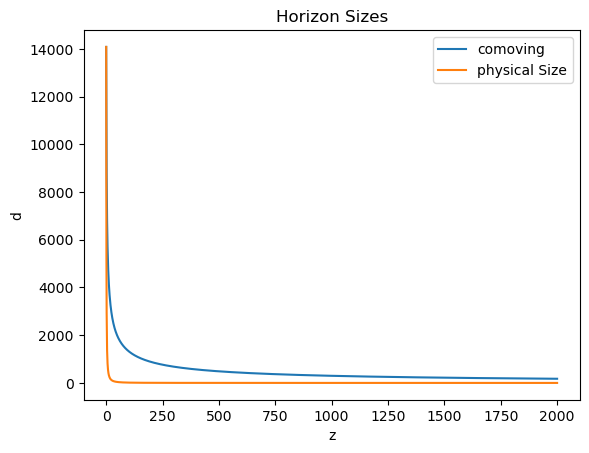

In [11]:
plt.plot(z_values,horizon_com)
plt.plot(z_values,d_a_horiz)
plt.xlabel('z')
plt.ylabel('d')
plt.legend(['comoving','physical Size'])
plt.title('Horizon Sizes')
plt.show()

The blue curve is at its maximum at $z=0$ because it represents the maximum distance light could have traveled from the beginning of the universe to the present day, and it decreases as $z$ increases. 

The orange curve represents the physical size of the horizon at time $t(z)$, which is even smaller since it is the comoving distance divided by $1+z$.

[           nan 1.00002596e+00 1.83576758e+00 ... 2.52633933e+04
 2.52839585e+04 2.53045313e+04]


/tmp/ipykernel_6307/1359735377.py:4: RuntimeWarning: invalid value encountered in cos
  solid = 2*np.pi*(1.0 - np.cos(angle))


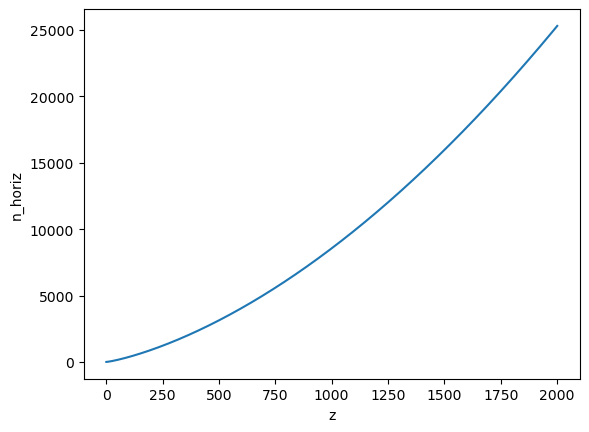

In [7]:
# Computing how many horizons needs to cover the sky at different redshifts
 
# Angular Solid Angle of the horizon at time t(z)
solid = 2*np.pi*(1.0 - np.cos(angle))

# Angular Solid Angle of the sky
sky_solid = 4*np.pi

# Number of horizons needed to cover the sky
n_horiz = sky_solid / solid
print(n_horiz)

plt.plot(z_values,n_horiz)
plt.xlabel('z')
plt.ylabel('n_horiz')
plt.show()

At $z=0$ (where we are today), the entire observable sky corresponds to our particle horizon. Therefore, only a single causal "patch" is needed to cover the entire observable universe. However, for $z>0$, the number of these patches grows rapidly. We observe many regions that were never in causal contact with one another, yet how is it possible that they all share the exact same temperature?

We can treat the different horizon patches as independent and identically distributed universes, constituting $n$ realizations of a Gaussian probability distribution. Assuming the true mean and variance are unknown, we consider the sample variance estimator formula:
$$
s_n^2 = \frac{1}{n-1}\sum_{i=1}^{n}\left(X_i-\overline{X}_n\right)^2
$$


Therefore, the scale of the variance for the test statistic at each redshift is:

$$s_n^2 \propto \frac{1}{n-1}$$


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6307/3811226776.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma^2 \propto 1/N$')


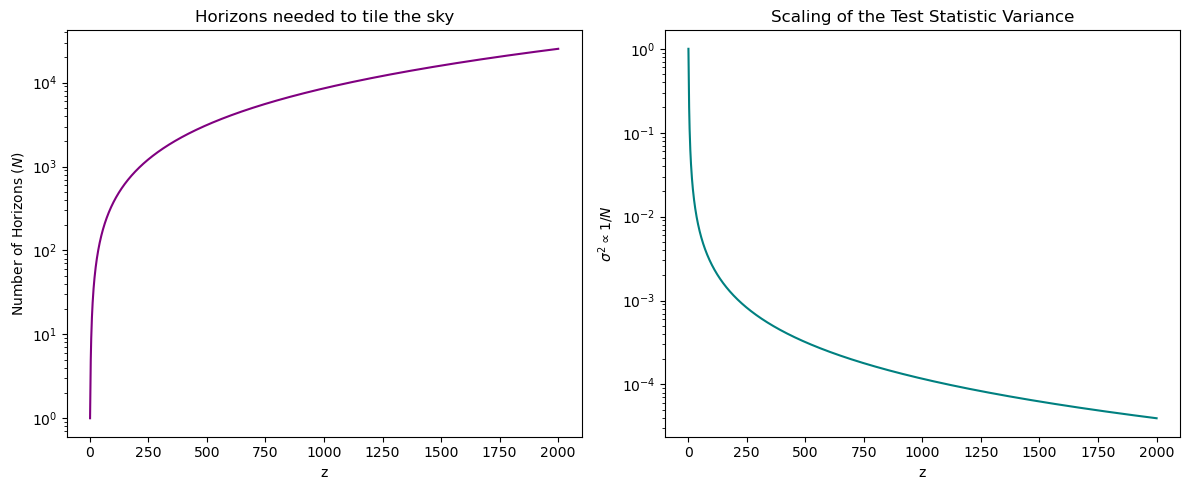

In [21]:
# Scaling of the variance of the test statistic (1 / N)
variance_scaling = 1 / n_horiz

plt.figure(figsize=(12, 5))

# Plot 1: Number of horizons
plt.subplot(1, 2, 1)
plt.plot(z_values, n_horiz, color='purple')
plt.xlabel('z')
plt.ylabel('Number of Horizons ($N$)')
plt.title('Horizons needed to tile the sky')
plt.yscale('log') # Consigliato per escursioni così ampie

# Plot 2: Scaling of the variance
plt.subplot(1, 2, 2)
plt.plot(z_values, variance_scaling, color='teal')
plt.xlabel('z')
plt.ylabel('$\sigma^2 \propto 1/N$')
plt.title('Scaling of the Test Statistic Variance')
plt.yscale('log')

plt.tight_layout()
plt.show()


At $z=0$, there is only a single sample, which is why the statistical uncertainty is at its maximum. 

At $z=2000$, there are $n_{\text{horiz}} = 25000$ samples, which reduces the uncertainty to a minimum.